In [114]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

In [115]:
df =pd.read_csv("reviews.csv")
df.head()

,reviewText,summary,overall,verified,vote
0,This was the first time I read Garcia-Aguilera...,Hit The Spot!,5.0,True,NaN
1,"As with all of Ms. Garcia-Aguilera's books, I ...",one hot summer is HOT HOT HOT!,5.0,False,NaN
2,I've not read any of Ms Aguilera's works befor...,One Hot Summer,5.0,False,2
3,This romance novel is right up there with the ...,I love this book!,4.0,False,3
4,Carolina Garcia Aguilera has done it again. S...,One Hot Book,5.0,False,NaN


In [116]:
df.tail()


,reviewText,summary,overall,verified,vote
19995,"Folks let me be honest, i ran through several ...",the best iPod thingy...must have,5.0,True,5
19996,This was nice while it worked. Something keep...,Worked for one trip,2.0,True,NaN
19997,I use this to play my iPod in the car...and it...,Simple Solution,5.0,True,NaN
19998,Just what my sister needed.,Four Stars,4.0,True,NaN
19999,works fine had some old tapes and it cleaned ...,works fine had some old tapes and it cleaned v...,5.0,True,NaN


In [117]:
df.shape

(20000, 5)

In [118]:
df.isna().sum()

reviewText        6
summary           5
overall           0
verified          0
vote          17046
dtype: int64

In [119]:
df.dtypes

reviewText     object
summary        object
overall       float64
verified         bool
vote           object
dtype: object

In [120]:
# reeoving unwanted columns
df.drop(['vote'],axis=1,inplace=True)
df.drop(['summary'],axis=1,inplace=True)
df

,reviewText,overall,verified
0,This was the first time I read Garcia-Aguilera...,5.0,True
1,"As with all of Ms. Garcia-Aguilera's books, I ...",5.0,False
2,I've not read any of Ms Aguilera's works befor...,5.0,False
3,This romance novel is right up there with the ...,4.0,False
4,Carolina Garcia Aguilera has done it again. S...,5.0,False
...,...,...,...
19995,"Folks let me be honest, i ran through several ...",5.0,True
19996,This was nice while it worked. Something keep...,2.0,True
19997,I use this to play my iPod in the car...and it...,5.0,True
19998,Just what my sister needed.,4.0,True


In [121]:
#removing  un necessary rows contain null value;
df.drop(df.index[df['reviewText'].isnull()],axis=0,inplace=True)

In [122]:
df.isna().sum()

reviewText    0
overall       0
verified      0
dtype: int64

In [123]:
#remove duplicates
df.drop_duplicates()

,reviewText,overall,verified
0,This was the first time I read Garcia-Aguilera...,5.0,True
1,"As with all of Ms. Garcia-Aguilera's books, I ...",5.0,False
2,I've not read any of Ms Aguilera's works befor...,5.0,False
3,This romance novel is right up there with the ...,4.0,False
4,Carolina Garcia Aguilera has done it again. S...,5.0,False
...,...,...,...
19995,"Folks let me be honest, i ran through several ...",5.0,True
19996,This was nice while it worked. Something keep...,2.0,True
19997,I use this to play my iPod in the car...and it...,5.0,True
19998,Just what my sister needed.,4.0,True


In [124]:
df.shape

(19994, 3)

In [125]:
df1 = df['overall'].value_counts()

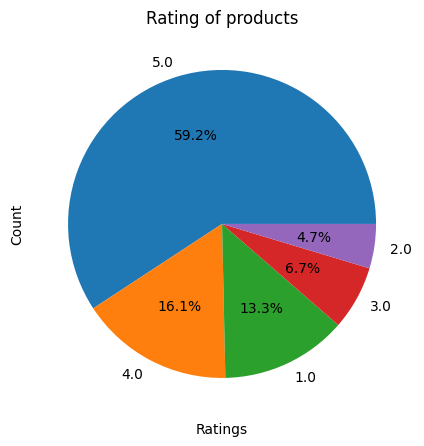

In [126]:
plt.figure(figsize=(8,5))
plt.pie(df1.values,labels=df1.index,autopct='%1.1f%%')
plt.title('Rating of products')
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.xticks()
plt.show()

In [127]:
df2= df['verified'].value_counts()
df2

verified
True     16896
False     3098
Name: count, dtype: int64

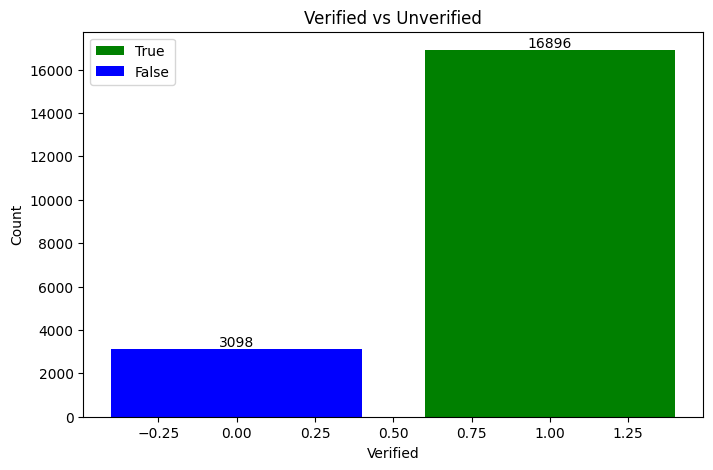

In [128]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
bars = plt.bar(df2.index, df2.values, color=['g','b'])
plt.xlabel('Verified')
plt.ylabel('Count')
plt.title('Verified vs Unverified')

# Legend
plt.legend(bars, ['True', 'False'])

# Add labels above bars automatically
plt.bar_label(bars, labels=df2.values, label_type='edge')

plt.show()

In [129]:
# converting true and false to 0s and 1s

df['verified']= df['verified'].astype(int)
df

,reviewText,overall,verified
0,This was the first time I read Garcia-Aguilera...,5.0,1
1,"As with all of Ms. Garcia-Aguilera's books, I ...",5.0,0
2,I've not read any of Ms Aguilera's works befor...,5.0,0
3,This romance novel is right up there with the ...,4.0,0
4,Carolina Garcia Aguilera has done it again. S...,5.0,0
...,...,...,...
19995,"Folks let me be honest, i ran through several ...",5.0,1
19996,This was nice while it worked. Something keep...,2.0,1
19997,I use this to play my iPod in the car...and it...,5.0,1
19998,Just what my sister needed.,4.0,1


In [130]:
df.dtypes

reviewText     object
overall       float64
verified        int64
dtype: object

In [131]:
review = df.reviewText
review

0        This was the first time I read Garcia-Aguilera...
1        As with all of Ms. Garcia-Aguilera's books, I ...
2        I've not read any of Ms Aguilera's works befor...
3        This romance novel is right up there with the ...
4        Carolina Garcia Aguilera has done it again.  S...
                               ...                        
19995    Folks let me be honest, i ran through several ...
19996    This was nice while it worked.  Something keep...
19997    I use this to play my iPod in the car...and it...
19998                          Just what my sister needed.
19999    works fine  had some old tapes and it cleaned ...
Name: reviewText, Length: 19994, dtype: object

In [132]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [133]:
#tokenization of the reviews

from nltk.tokenize import TweetTokenizer
tk = TweetTokenizer()
review =review.apply(lambda x: tk.tokenize(x)).apply(lambda x: ' '.join(x))
review

0        This was the first time I read Garcia-Aguilera...
1        As with all of Ms . Garcia-Aguilera's books , ...
2        I've not read any of Ms Aguilera's works befor...
3        This romance novel is right up there with the ...
4        Carolina Garcia Aguilera has done it again . S...
                               ...                        
19995    Folks let me be honest , i ran through several...
19996    This was nice while it worked . Something keep...
19997    I use this to play my iPod in the car ... and ...
19998                         Just what my sister needed .
19999    works fine had some old tapes and it cleaned v...
Name: reviewText, Length: 19994, dtype: object

In [134]:
# remove special characters

review = review.replace('[^a-zA-Z0-9]',' ',regex=True)
review

0        This was the first time I read Garcia Aguilera...
1        As with all of Ms   Garcia Aguilera s books   ...
2        I ve not read any of Ms Aguilera s works befor...
3        This romance novel is right up there with the ...
4        Carolina Garcia Aguilera has done it again   S...
                               ...                        
19995    Folks let me be honest   i ran through several...
19996    This was nice while it worked   Something keep...
19997    I use this to play my iPod in the car     and ...
19998                         Just what my sister needed  
19999    works fine had some old tapes and it cleaned v...
Name: reviewText, Length: 19994, dtype: object

In [135]:
#taking only meaningful word
from nltk.tokenize import word_tokenize
review = review.apply(lambda x:' '.join([w for w in word_tokenize(x) if len(w) >=3]))
review

0        This was the first time read Garcia Aguilera c...
1        with all Garcia Aguilera books think this MUST...
2        not read any Aguilera works before but after h...
3        This romance novel right there with the rest h...
4        Carolina Garcia Aguilera has done again She wr...
                               ...                        
19995    Folks let honest ran through several loops til...
19996    This was nice while worked Something keeps the...
19997    use this play iPod the car and works flawlessl...
19998                              Just what sister needed
19999    works fine had some old tapes and cleaned vcr ...
Name: reviewText, Length: 19994, dtype: object

In [136]:
# stemming using snowball stemming

from nltk.stem import SnowballStemmer
st = SnowballStemmer('english')
review = review.apply(lambda x:[st.stem(i.lower()) for i in tk.tokenize(x)]).apply(lambda x:' '.join(x))
review

0        this was the first time read garcia aguilera c...
1        with all garcia aguilera book think this must ...
2        not read ani aguilera work befor but after hav...
3        this romanc novel right there with the rest he...
4        carolina garcia aguilera has done again she wr...
                               ...                        
19995    folk let honest ran through sever loop till pu...
19996    this was nice while work someth keep the inter...
19997    use this play ipod the car and work flawless w...
19998                                just what sister need
19999    work fine had some old tape and clean vcr afte...
Name: reviewText, Length: 19994, dtype: object

In [137]:
# removing stopwords (but keep negation words)

from nltk.corpus import stopwords
stop = set(stopwords.words('english'))

# Keep important negation words
negations = {'not', 'no', 'nor', 'neither', 'never', 'nobody', 'nothing', 'nowhere', 'none'}
stop = stop - negations

review =  review.apply(lambda x: [i for i in tk.tokenize(x) if i not in stop]).apply(lambda x: ' '.join(x))
review

0        first time read garcia aguilera came upon name...
1        garcia aguilera book think must read imposs pu...
2        read ani aguilera work befor finish one hot su...
3        romanc novel right rest amaz mysteri novel guy...
4        carolina garcia aguilera done written anoth hi...
                               ...                        
19995    folk let honest ran sever loop till put money ...
19996    nice work someth keep intern gear turn continu...
19997    use play ipod car work flawless work great sim...
19998                                          sister need
19999      work fine old tape clean vcr view mani old tape
Name: reviewText, Length: 19994, dtype: object

In [138]:
# vectorization - Store processed text first, don't vectorize yet

from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(ngram_range=(1, 2),max_df=0.9,min_df=5)

# Store processed reviews as text for now
reviews = review
reviews

0        first time read garcia aguilera came upon name...
1        garcia aguilera book think must read imposs pu...
2        read ani aguilera work befor finish one hot su...
3        romanc novel right rest amaz mysteri novel guy...
4        carolina garcia aguilera done written anoth hi...
                               ...                        
19995    folk let honest ran sever loop till put money ...
19996    nice work someth keep intern gear turn continu...
19997    use play ipod car work flawless work great sim...
19998                                          sister need
19999      work fine old tape clean vcr view mani old tape
Name: reviewText, Length: 19994, dtype: object

In [139]:
# 
def label_sentiment(rating):
    if rating <=2:
        return -1
    elif rating == 3:
        return 0
    else:
        return 1
df['y'] = df['overall'].apply(lambda x: label_sentiment(x))
df

,reviewText,overall,verified,y
0,This was the first time I read Garcia-Aguilera...,5.0,1,1
1,"As with all of Ms. Garcia-Aguilera's books, I ...",5.0,0,1
2,I've not read any of Ms Aguilera's works befor...,5.0,0,1
3,This romance novel is right up there with the ...,4.0,0,1
4,Carolina Garcia Aguilera has done it again. S...,5.0,0,1
...,...,...,...,...
19995,"Folks let me be honest, i ran through several ...",5.0,1,1
19996,This was nice while it worked. Something keep...,2.0,1,-1
19997,I use this to play my iPod in the car...and it...,5.0,1,1
19998,Just what my sister needed.,4.0,1,1


In [140]:
#splitting input and output

x=reviews
y=df['y']


In [141]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test  =  train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((15995,), (3999,), (15995,), (3999,))

In [142]:
# FIT vectorizer on training data only, then transform both train and test
x_train = vectorizer.fit_transform(x_train)
x_test = vectorizer.transform(x_test)

x_train.shape, x_test.shape

((15995, 18644), (3999, 18644))

In [143]:
y.value_counts()

y
 1    15064
-1     3583
 0     1347
Name: count, dtype: int64

In [143]:
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("Test distribution:")
print(y_test.value_counts(normalize=True))


Train distribution:
y
 1    0.750672
-1    0.180994
 0    0.068334
Name: proportion, dtype: float64
Test distribution:
y
 1    0.764441
-1    0.172043
 0    0.063516
Name: proportion, dtype: float64


In [144]:
#building logistic regression model
from sklearn.linear_model import LogisticRegression
model =LogisticRegression(max_iter=1000,class_weight='balanced',multi_class='auto')
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
y_pred

C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


array([1, 1, 1, ..., 1, 1, 1], shape=(3999,))

In [145]:
#evaluation
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

print(classification_report(
    y_test,
    y_pred,
    target_names=['Negative', 'Neutral', 'Positive']
))


              precision    recall  f1-score   support

    Negative       0.68      0.79      0.73       688
     Neutral       0.20      0.37      0.26       254
    Positive       0.94      0.84      0.89      3057

    accuracy                           0.80      3999
   macro avg       0.61      0.67      0.62      3999
weighted avg       0.85      0.80      0.82      3999



In [146]:
print(confusion_matrix(y_test,y_pred))

print('\n',accuracy_score(y_test,y_pred))

[[ 541   78   69]
 [  75   94   85]
 [ 182  310 2565]]

 0.8002000500125032


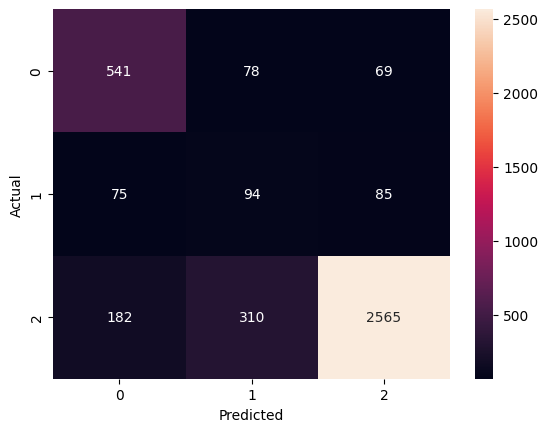

In [147]:
#confusion matric display
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, y_pred),annot=True,fmt='d',cmap='rocket')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

PURCHASE INTENT ANALYZER


In [148]:
# create a new column named purchase_intent
def map_purchase_intent(rating):
    if rating <= 2:
        return "Low"
    elif rating == 3:
        return "Medium"
    else:
        return "High"

df["purchase_intent"] = df["overall"].apply(map_purchase_intent)
df["purchase_intent"].value_counts()


purchase_intent
High      15064
Low        3583
Medium     1347
Name: count, dtype: int64

In [ ]:
# drop invalid rows
df_intent = df.dropna(subset=['overall', 'reviewText'])

,reviewText,overall,verified,y,purchase_intent
0,This was the first time I read Garcia-Aguilera...,5.0,1,1,High
1,"As with all of Ms. Garcia-Aguilera's books, I ...",5.0,0,1,High
2,I've not read any of Ms Aguilera's works befor...,5.0,0,1,High
3,This romance novel is right up there with the ...,4.0,0,1,High
4,Carolina Garcia Aguilera has done it again. S...,5.0,0,1,High
...,...,...,...,...,...
19995,"Folks let me be honest, i ran through several ...",5.0,1,1,High
19996,This was nice while it worked. Something keep...,2.0,1,-1,Low
19997,I use this to play my iPod in the car...and it...,5.0,1,1,High
19998,Just what my sister needed.,4.0,1,1,High


In [156]:
df_intent.shape

(19994, 5)

In [157]:
# x and y
x1 = df_intent['reviewText']
y1 = df_intent['purchase_intent']


In [158]:
#train_test_split
x1_train,x1_test,y1_train,y1_test = train_test_split(x1,y1,test_size=0.2,random_state=42)
x1_train.shape,x1_test.shape,y1_train.shape,y1_test.shape

((15995,), (3999,), (15995,), (3999,))

In [ ]:
#tf-idf transform - MUST transform training data too

x1_train = vectorizer.transform(x1_train)
x1_test = vectorizer.transform(x1_test)

In [160]:
#model creation

intent_model = LogisticRegression(max_iter =1000, multi_class='multinomial')
intent_model.fit(x1_train,y1_train)

y1_pred = intent_model.predict(x1_test)
y1_pred

C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


array(['High', 'High', 'High', ..., 'High', 'High', 'High'],
      shape=(3999,), dtype=object)

In [161]:
print("Accuracy:", accuracy_score(y1_test, y1_pred))
print("\nClassification Report:\n")
print(classification_report(y1_test, y1_pred))

Accuracy: 0.8777194298574643

Classification Report:

              precision    recall  f1-score   support

        High       0.89      0.99      0.93      3057
         Low       0.83      0.71      0.77       688
      Medium       0.40      0.03      0.06       254

    accuracy                           0.88      3999
   macro avg       0.71      0.58      0.59      3999
weighted avg       0.85      0.88      0.85      3999



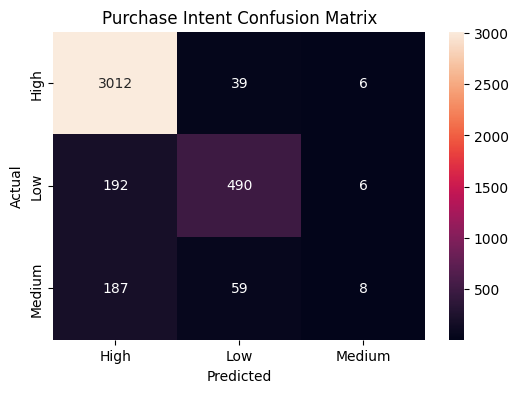

In [162]:
cm_intent = confusion_matrix(y1_test, y1_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm_intent, annot=True, fmt="d",
            xticklabels=intent_model.classes_,
            yticklabels=intent_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Purchase Intent Confusion Matrix")
plt.show()

In [ ]:
#save model in pickle file

import pickle
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))
pickle.dump(model, open("sentiment_model.pkl", "wb"))
pickle.dump(intent_model, open("purchase_intent_model.pkl", "wb"))

print("✅ TF-IDF, sentiment model, and purchase intent model saved successfully")



✅ TF-IDF, sentiment model, and purchase intent model saved successfully


In [ ]:
# Preprocessing function for new reviews (must match training preprocessing)

def preprocess_review(text):
    """
    Preprocess a single review text the same way as training data.
    This function MUST be used before prediction.
    """
    from nltk.tokenize import TweetTokenizer, word_tokenize
    from nltk.stem import SnowballStemmer
    from nltk.corpus import stopwords
    import re
    
    # Initialize tools
    tk = TweetTokenizer()
    st = SnowballStemmer('english')
    stop = set(stopwords.words('english'))
    
    # Keep negation words - critical for sentiment
    negations = {'not', 'no', 'nor', 'neither', 'never', 'nobody', 'nothing', 'nowhere', 'none'}
    stop = stop - negations
    
    # Tokenization
    text = ' '.join(tk.tokenize(text))
    
    # Remove special characters
    text = re.sub(r'[^a-zA-Z0-9]', ' ', text)
    
    # Keep only words with 3+ characters
    text = ' '.join([w for w in word_tokenize(text) if len(w) >= 3])
    
    # Stemming
    text = ' '.join([st.stem(i.lower()) for i in tk.tokenize(text)])
    
    # Remove stopwords
    text = ' '.join([i for i in tk.tokenize(text) if i not in stop])
    
    return text

# Save preprocessing function too
pickle.dump(preprocess_review, open("preprocess_function.pkl", "wb"))
print("✅ Preprocessing function saved")

In [ ]:
# TEST: Example of how to use the models for prediction

test_review = "This product is amazing! Best purchase ever!"

# Step 1: Preprocess the review
processed = preprocess_review(test_review)
print(f"Original: {test_review}")
print(f"Processed: {processed}")

# Step 2: Vectorize using the fitted vectorizer
vectorized = vectorizer.transform([processed])

# Step 3: Predict sentiment
sentiment = model.predict(vectorized)[0]
sentiment_proba = model.predict_proba(vectorized)[0]

# Step 4: Predict purchase intent
intent = intent_model.predict(vectorized)[0]
intent_proba = intent_model.predict_proba(vectorized)[0]

print(f"\nSentiment: {sentiment}")
print(f"Sentiment Probabilities: {sentiment_proba}")
print(f"\nPurchase Intent: {intent}")
print(f"Intent Probabilities: {intent_proba}")
